In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt
from torchsummary import summary

In [2]:
# 데이터셋 로드
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/TSLA.csv')
data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500
1,2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500
2,2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000
3,2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000
4,2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500
...,...,...,...,...,...,...,...
2951,2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500
2952,2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200
2953,2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500
2954,2022-03-23,979.940002,1040.699951,976.400024,999.109985,999.109985,40225400


In [3]:
# 사용할 칼럼 지정

X = data[['Open', 'High', 'Low', 'Close']]  # 피쳐 수 : 4
y=data['Close']

print("--- 입력 데이터 (X) ---")
print(X.head())
print("\n--- 정답 데이터 (y) ---")
print(y.head())

--- 입력 데이터 (X) ---
    Open   High    Low  Close
0  3.800  5.000  3.508  4.778
1  5.158  6.084  4.660  4.766
2  5.000  5.184  4.054  4.392
3  4.600  4.620  3.742  3.840
4  4.000  4.000  3.166  3.222

--- 정답 데이터 (y) ---
0    4.778
1    4.766
2    4.392
3    3.840
4    3.222
Name: Close, dtype: float64


In [4]:
# 정규화

# X용, y용 스케일러를 각각 따로 선언
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# 숫자 칼럼만 골라서 정규화 진행
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

print("X_scaled shape:", X_scaled.shape)
print("y_scaled shape:", y_scaled.shape)

X_scaled shape: (2956, 4)
y_scaled shape: (2956, 1)


In [5]:
# 시퀀스 생성 : Sliding Window
X_raw = np.array(X_scaled)
y_raw = np.array(y_scaled)

def make_sample(X_data, y_data, window):
  train, target = [], []
  for i in range(len(X_data)-window):
      train.append(X_data[i:i+window])
      target.append(y_data[i+window])
  return np.array(train), np.array(target)

# 윈도우 7로 설정하여 데이터 생성 : 7일치를 보고 8일차 종가 예측
X_rnn, y_rnn = make_sample(X_raw, y_raw, 7)

# 결과 출력
print("X_rnn shape:", X_rnn.shape)  # (2949, 7, 4) -> (샘플 수, 시퀀스 길이, 피처 수)
print("y_rnn shape:", y_rnn.shape)
print("\n--- 첫 번째 샘플의 X (7일치 데이터) ---")
print(X_rnn[0])
print("\n--- 첫 번째 샘플의 y (8일차 예측 종가) ---")
print(y_rnn[0])

X_rnn shape: (2949, 7, 4)
y_rnn shape: (2949, 1)

--- 첫 번째 샘플의 X (7일치 데이터) ---
[[4.64594174e-04 1.34982149e-03 4.21744904e-04 1.31893210e-03]
 [1.56759922e-03 2.22389944e-03 1.37067094e-03 1.30915016e-03]
 [1.43926727e-03 1.49818896e-03 8.71496305e-04 1.00427957e-03]
 [1.11437624e-03 1.04341040e-03 6.14495504e-04 5.54310154e-04]
 [6.27039689e-04 5.43476512e-04 1.40032488e-04 5.05400434e-05]
 [4.22358340e-05 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.43529405e-04 9.71990208e-05 2.70633781e-04]]

--- 첫 번째 샘플의 y (8일차 예측 종가) ---
[0.00026085]


In [6]:
# Train/Test 분할
# 전체 샘플 개수의 80% 지점 계산
split_index = int(len(X_rnn) * 0.8)

# 순서대로 8:2 분할
X_train, X_test = X_rnn[:split_index], X_rnn[split_index:]
y_train, y_test = y_rnn[:split_index], y_rnn[split_index:]

print("--- 시계열 분할 결과 ---")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

--- 시계열 분할 결과 ---
X_train shape: (2359, 7, 4)
X_test shape: (590, 7, 4)
y_train shape: (2359, 1)
y_test shape: (590, 1)


In [7]:
# 모델 빌딩
tf.keras.backend.clear_session()

model = Sequential([
    Input(shape=(7, 4)),                                      # 윈도우 7, 피처 4 명시
    SimpleRNN(64, activation='tanh', return_sequences=True),  # 다음 RNN으로 넘겨주기 위해 True 유지
    SimpleRNN(32, activation='tanh'),                         # 마지막 RNN 레이어
    Dense(1)                                                  # 주가 예측용 출력층
])
model.compile(optimizer='adam', loss='mse')

In [8]:
# 모델 학습
history = model.fit(
            X_train, y_train,
            epochs=100,
            batch_size=32,
            validation_split=0.2,
            verbose=1
        )

Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 3.4469e-04 - val_loss: 8.7116e-06
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.6473e-06 - val_loss: 7.6711e-06
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8773e-06 - val_loss: 6.8169e-06
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6394e-06 - val_loss: 5.8743e-06
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.4663e-06 - val_loss: 5.5541e-06
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3407e-06 - val_loss: 5.1075e-06
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.4502e-06 - val_loss: 4.9391e-06
Epoch 8/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3910e-06 - val_loss: 4.8915e-06
Epoch 9/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2535e-06 - val_loss: 4.8032e-06
Epoch 10/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2561e-06 - val_loss: 4.7810e-06
Epoch 11/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2741e-

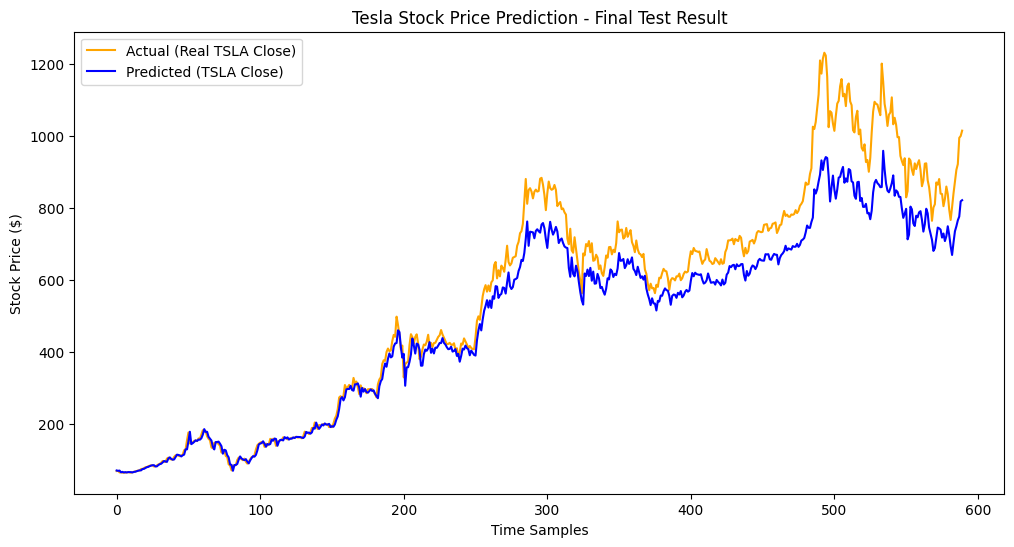

In [9]:
# 모델 테스트 및 시각화

# 테스트 단계 : X_test로 미래 주가 예측
y_pred_scaled = model.predict(X_test, verbose=0)

# 시각화를 위해 0~1로 압축됐던 값을 원래 주가($ 단위)로 복원
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test)

# 시각화1
plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label="Actual (Real TSLA Close)", color="orange")
plt.plot(y_pred, label="Predicted (TSLA Close)", color="blue")
plt.title("Tesla Stock Price Prediction - Final Test Result")
plt.xlabel("Time Samples")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.show()

X_cosine shape: (993, 7, 4)
y_cosine shape: (993,)


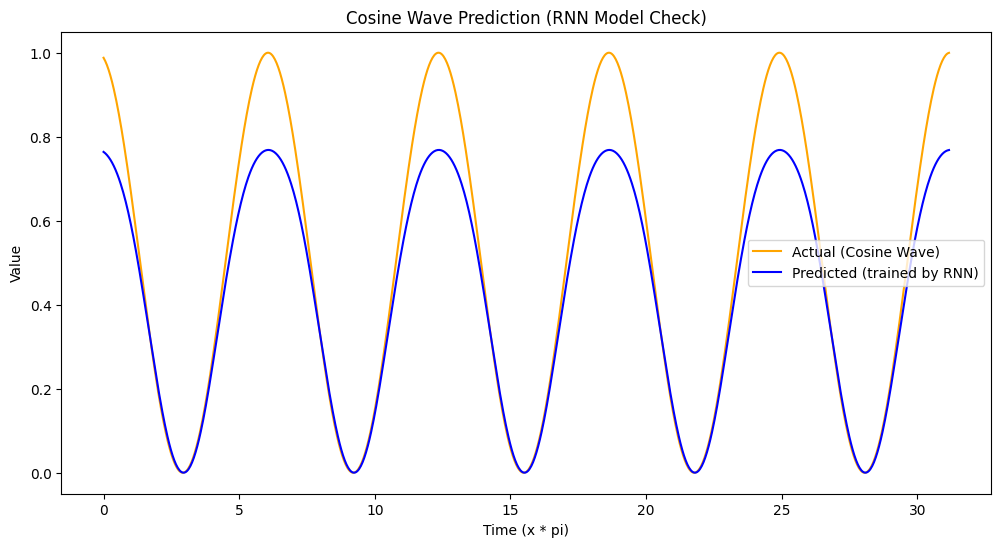

In [10]:
# 시각화2 : 코사인 그래프

# 1. 시각화용 코사인 데이터 생성
# 코사인 데이터 및 시간 축 정의
time = np.pi * np.arange(0, 1000) * 0.01
seq_data = (np.cos(time) + 1) / 2

# 4개 피쳐(Open, High, Low, Close)에 맞게 (1000, 4)로 확장
cosine_data = np.tile(seq_data.reshape(-1, 1), (1, 4))

# 2.윈도우 적용 (윈도우 = 7)
X_cosine, y_cosine = make_sample(cosine_data, seq_data, 7)
print("X_cosine shape:", X_cosine.shape)
print("y_cosine shape:", y_cosine.shape)

# 3. 모델을 통해 코사인 값 예측 수행
y_pred_cosine = model.predict(X_cosine, verbose=0)

# 4. 코사인 곡선 시각화
plt.figure(figsize=(12, 6))

time_axis = np.pi * np.arange(0, len(y_cosine)) * 0.01

plt.plot(time_axis, y_cosine, label="Actual (Cosine Wave)", color="orange")
plt.plot(time_axis, y_pred_cosine, label="Predicted (trained by RNN)", color="blue")

plt.title("Cosine Wave Prediction (RNN Model Check)")
plt.xlabel("Time (x * pi)")
plt.ylabel("Value")
plt.legend()
plt.show()